# Hybrid Final — EfficientNet + HOG + HSV (Versi Bersih)
**Ghania Fazila — 41122100060**

**Prasyarat:** `eff_best.pt` dari notebook EfficientNet Fine-tune (Tahap 1).

**Isi notebook:**
1. Setup & Konfigurasi
2. Transform, HOG/HSV, PKSampler, Dataset, Model
3. Transfer backbone dari `eff_best.pt` → Training hybrid
4. Resume checkpoint (jika runtime disconnect)
5. Baseline Comparison 4 skenario (tabel resmi Bab 4)
6. Alpha Sweep
7. Build database PDKI
8. Demo retrieval
9. EigenGradCAM (XAI)
10. Ringkasan & checklist download

## Cell 1 — Install & Import

In [1]:
!pip install -q pytorch-metric-learning grad-cam
import os, json, random
import numpy as np
import torch, torch.nn as nn
import torchvision.transforms as T
import matplotlib.pyplot as plt
import pandas as pd
import cv2
from pathlib import Path
from PIL import Image
from tqdm import tqdm
from torchvision import models
from torch.utils.data import Dataset, DataLoader, Sampler
from skimage.feature import hog
from sklearn.metrics.pairwise import cosine_similarity
from pytorch_metric_learning import miners, losses

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BASE_IN1  = '/kaggle/input/datasets/ghaniafazila/trademark-logo'
BASE_IN2  = '/kaggle/input/datasets/ghaniafazila/skripsi'
BASE_OUT = '/kaggle/working'

for d in ['models', 'results', 'results/heatmaps', 'results/bab4']:
    os.makedirs(f'{BASE_OUT}/{d}', exist_ok=True)

print(f'Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU   : {torch.cuda.get_device_name(0)}')
print(f'torch     : {torch.__version__}')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 67.4 MB/s eta 0:00:00:00:010:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.8/127.8 kB 8.2 MB/s eta 0:00:00
Device: cuda
GPU   : Tesla T4
torch     : 2.10.0+cu128


## Cell 2 — Konfigurasi Global

In [2]:
# ===================== PATH =====================
FOOD_CLEAN_JSON  = f'{BASE_IN2}/Clean_Dataset/clean_brands_food.json'  # hasil filter noise
FOOD_DIR         = f'{BASE_IN1}/Food/Food'      
METU_QUERY_DIR   = f'{BASE_IN1}/metu_query/metu_query'
PDKI_DIR         = f'{BASE_IN2}/PDKI'                       # !! sesuaikan nama folder PDKI kamu !!

# ===================== HYPERPARAMETER =====================
IMG_SIZE             = 224
EMBED_DIM            = 256
MARGIN               = 0.3
LR                   = 5e-5
NUM_EPOCHS           = 20
EARLY_STOP_PATIENCE  = 5
N_BLOCKS_TRAINABLE   = 2
P_PER_BATCH          = 8
K_PER_CLASS          = 6
BATCH_SIZE           = P_PER_BATCH * K_PER_CLASS   # 48
NUM_WORKERS          = 2
TOP_K                = 10
ALPHA_FUSION         = 0.8   # bobot hybrid score vs color score di late fusion

# ===================== TRANSFER LEARNING =====================
# Path ke .pt EfficientNet-only (Food Clean, mAP 0.6733)
# Set None atau "" untuk training dari nol
PRETRAINED_EFF_PATH = f'{BASE_IN2}/eff_best.pt'   # dari notebook EfficientNet Tahap 1

# ===================== HOG PARAMS =====================
HOG_ORIENTATIONS    = 9
HOG_PIXELS_PER_CELL = (8, 8)
HOG_CELLS_PER_BLOCK = (2, 2)
HSV_BINS            = [16, 8, 8]

HYBRID_CKPT_PATH   = f'{BASE_OUT}/models/hybrid_best2.pt'
HYBRID_RESUME_PATH = f'{BASE_OUT}/models/hybrid_resume.pt'

print('Konfigurasi global siap.')
print(f'  BATCH_SIZE   : {BATCH_SIZE} (P={P_PER_BATCH} x K={K_PER_CLASS})')
print(f'  EMBED_DIM    : {EMBED_DIM}')
print(f'  ALPHA_FUSION : {ALPHA_FUSION}')

Konfigurasi global siap.
  BATCH_SIZE   : 48 (P=8 x K=6)
  EMBED_DIM    : 256
  ALPHA_FUSION : 0.8


## Cell 3 — Transform Pipeline (Dua Jalur)

In [3]:
class LetterboxResize:
    def __init__(self, size=224):
        self.size = size
    def __call__(self, img):
        img = img.convert('RGB')
        w, h = img.size
        scale = self.size / max(w, h)
        img = img.resize((max(1,int(w*scale)), max(1,int(h*scale))), Image.LANCZOS)
        canvas = Image.new('RGB', (self.size, self.size), (0, 0, 0))
        canvas.paste(img, ((self.size-img.width)//2, (self.size-img.height)//2))
        return canvas

# Jalur A: EfficientNet (dengan color jitter + standarisasi ImageNet)
tf_eff_train = T.Compose([
    LetterboxResize(IMG_SIZE), T.ToTensor(),
    T.RandomRotation(15), T.RandomHorizontalFlip(0.5),
    T.RandomAffine(0, translate=(0.05,0.05), shear=5),
    T.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])
tf_eff_val = T.Compose([
    LetterboxResize(IMG_SIZE), T.ToTensor(),
    T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

# Jalur B/C: HOG + HSV (TANPA color jitter, TANPA standarisasi ImageNet)
tf_hc_train = T.Compose([
    LetterboxResize(IMG_SIZE), T.ToTensor(),
    T.RandomRotation(15), T.RandomHorizontalFlip(0.5),
    T.RandomAffine(0, translate=(0.05,0.05), shear=5),
])
tf_hc_val = T.Compose([LetterboxResize(IMG_SIZE), T.ToTensor()])

print('Transform pipeline siap (dua jalur terpisah).')

Transform pipeline siap (dua jalur terpisah).


## Cell 4 — Fungsi Ekstraksi HOG & HSV

In [4]:
def extract_hog(tensor_img):
    img_np = (tensor_img.permute(1,2,0).numpy()*255).astype(np.uint8)
    gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
    return hog(gray, orientations=HOG_ORIENTATIONS,
               pixels_per_cell=HOG_PIXELS_PER_CELL,
               cells_per_block=HOG_CELLS_PER_BLOCK,
               block_norm='L2-Hys', feature_vector=True).astype(np.float32)

def extract_hsv_histogram(tensor_img):
    img_np = (tensor_img.permute(1,2,0).numpy()*255).astype(np.uint8)
    hsv = cv2.cvtColor(img_np, cv2.COLOR_RGB2HSV)
    h = cv2.calcHist([hsv],[0],None,[HSV_BINS[0]],[0,180]).flatten()
    s = cv2.calcHist([hsv],[1],None,[HSV_BINS[1]],[0,256]).flatten()
    v = cv2.calcHist([hsv],[2],None,[HSV_BINS[2]],[0,256]).flatten()
    hist = np.concatenate([h, s, v])
    if hist.sum() > 0:
        hist = hist / hist.sum()
    return hist.astype(np.float32)

# Cek dimensi
_t = tf_hc_val(LetterboxResize(IMG_SIZE)(Image.new('RGB',(100,100))))
HOG_DIM = len(extract_hog(_t))
HSV_DIM = len(extract_hsv_histogram(_t))
print(f'HOG_DIM: {HOG_DIM}')
print(f'HSV_DIM: {HSV_DIM}')

HOG_DIM: 26244
HSV_DIM: 32


## Cell 5 — PKSampler

In [5]:
class PKSampler(Sampler):
    def __init__(self, labels, p, k):
        self.labels = np.array(labels)
        self.unique_labels = np.unique(self.labels)
        self.label_to_indices = {
            lbl: np.where(self.labels==lbl)[0] for lbl in self.unique_labels
        }
        self.usable_labels = np.array([
            lbl for lbl in self.unique_labels if len(self.label_to_indices[lbl]) >= k
        ])
        self.p, self.k = p, k
        self.n_batches = max(len(self.labels) // (p*k), 1)

    def __iter__(self):
        pool = self.usable_labels.copy()
        for _ in range(self.n_batches):
            np.random.shuffle(pool)
            batch_labels = pool[:self.p] if len(pool)>=self.p else \
                           np.random.choice(pool, self.p, replace=True)
            batch_idx = []
            for lbl in batch_labels:
                idx = self.label_to_indices[lbl]
                batch_idx.extend(np.random.choice(idx, self.k,
                                  replace=len(idx)<self.k).tolist())
            yield batch_idx

    def __len__(self): return self.n_batches

print('PKSampler v2 siap.')

PKSampler v2 siap.


## Cell 6 — Dataset Logo-2K+ Food Clean

In [6]:
class Logo2KCleanDataset(Dataset):
    """
    Logo-2K+ yang sudah difilter noise.
    Setiap item kembalikan TIGA output:
    - img_eff  : tensor untuk EfficientNet (dengan color jitter, standarisasi ImageNet)
    - hog_vec  : HOG dari jalur handcrafted (tanpa color jitter)
    - label    : index kelas brand
    HSV disimpan TERPISAH sebagai file .npy (pre-computed, untuk efisiensi)
    """
    def __init__(self, root_dir, clean_brands_json=None, max_samples=None,
                  is_train=True, validate=True):
        self.root_dir = Path(root_dir)
        self.is_train = is_train
        self.tf_eff = tf_eff_train if is_train else tf_eff_val
        self.tf_hc  = tf_hc_train  if is_train else tf_hc_val

        # Load daftar brand bersih
        clean_brand_set = None
        if clean_brands_json:
            with open(clean_brands_json) as f:
                data = json.load(f)
            clean_brand_set = set(data['clean_brands'])
            print(f'Filter aktif: {len(clean_brand_set)} brand bersih dimuat dari JSON')

        # Kumpulkan semua path
        all_paths = list(self.root_dir.rglob('*.jpg')) + \
                    list(self.root_dir.rglob('*.jpeg')) + \
                    list(self.root_dir.rglob('*.png'))

        # Group per brand, filter clean_brand_set jika ada
        per_brand = {}
        for p in all_paths:
            brand = p.parent.name
            if clean_brand_set and brand not in clean_brand_set:
                continue
            per_brand.setdefault(brand, []).append(p)

        # Filter brand minimal K samples
        per_brand = {b: ps for b, ps in per_brand.items() if len(ps) >= K_PER_CLASS}

        brand_names = sorted(per_brand.keys())
        self.class_to_idx = {b: i for i, b in enumerate(brand_names)}
        self.samples = []
        for b in brand_names:
            for p in per_brand[b]:
                self.samples.append((p, self.class_to_idx[b]))

        if max_samples and len(self.samples) > max_samples:
            random.seed(42)
            random.shuffle(self.samples)
            self.samples = self.samples[:max_samples]

        if validate:
            valid = []
            for p, lbl in tqdm(self.samples, desc='Validasi gambar'):
                try:
                    img = Image.open(p); img.verify()
                    valid.append((p, lbl))
                except: continue
            n_drop = len(self.samples) - len(valid)
            if n_drop > 0:
                print(f'{n_drop} file corrupt difilter')
            self.samples = valid

        self.labels = [lbl for _, lbl in self.samples]
        print(f'Dataset siap: {len(self.samples)} gambar, {len(set(self.labels))} brand unik')

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        try: img_raw = Image.open(path).convert('RGB')
        except: img_raw = Image.open(self.samples[(idx+1)%len(self.samples)][0]).convert('RGB')

        img_eff = self.tf_eff(img_raw)
        img_hc  = self.tf_hc(img_raw)
        hog_vec = extract_hog(img_hc)

        return (img_eff,
                torch.tensor(hog_vec, dtype=torch.float32),
                torch.tensor(label, dtype=torch.long))


train_ds = Logo2KCleanDataset(FOOD_DIR, clean_brands_json=FOOD_CLEAN_JSON, is_train=True)
sampler  = PKSampler(train_ds.labels, p=P_PER_BATCH, k=K_PER_CLASS)
train_loader = DataLoader(train_ds, batch_sampler=sampler, num_workers=NUM_WORKERS)
print(f'Batches per epoch: {len(sampler)}')

Filter aktif: 214 brand bersih dimuat dari JSON


Validasi gambar: 100%|██████████| 10689/10689 [00:54<00:00, 197.24it/s]

Dataset siap: 10689 gambar, 214 brand unik
Batches per epoch: 222


## Cell 7 — Arsitektur Hybrid Model

In [7]:
class HybridLogoModel(nn.Module):
    def __init__(self, hog_dim, embed_dim=256, n_blocks_trainable=2):
        super().__init__()
        eff = models.efficientnet_v2_s(weights='IMAGENET1K_V1')
        self.backbone = nn.Sequential(*list(eff.children())[:-1])
        self.pool = nn.AdaptiveAvgPool2d(1)
        deep_dim = 1280

        # Freeze per BLOK (terbukti benar dari eksperimen sebelumnya)
        blocks = list(self.backbone[0].children())
        for p in self.backbone.parameters(): p.requires_grad = False
        for block in blocks[-n_blocks_trainable:]:
            for p in block.parameters(): p.requires_grad = True

        hog_proj_dim = 256
        self.hog_proj = nn.Sequential(
            nn.Linear(hog_dim, hog_proj_dim), nn.BatchNorm1d(hog_proj_dim),
            nn.ReLU(), nn.Dropout(0.3),
        )
        fusion_dim = deep_dim + hog_proj_dim
        self.embedding_layer = nn.Sequential(
            nn.Linear(fusion_dim, 512),  # ← ganti deep_dim → fusion_dim
            nn.BatchNorm1d(512),
            nn.SiLU(),
            nn.Linear(512, embed_dim)
        )

        n_train = sum(p.numel() for p in self.parameters() if p.requires_grad)
        n_total = sum(p.numel() for p in self.parameters())
        print(f'Trainable: {n_train:,} / {n_total:,} ({n_train/n_total*100:.1f}%)')

    def forward(self, img, hog_vec):
        deep = self.backbone(img)
        deep = self.pool(deep).flatten(1)
        hog  = self.hog_proj(hog_vec)
        fused = torch.cat([deep, hog], dim=1)
        embed = self.embedding_layer(fused)
        return nn.functional.normalize(embed, p=2, dim=1)

model = HybridLogoModel(HOG_DIM, EMBED_DIM, N_BLOCKS_TRAINABLE).to(DEVICE)
print('HybridLogoModel siap.')

Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:00<00:00, 177MB/s]


Trainable: 22,530,600 / 27,816,016 (81.0%)
HybridLogoModel siap.


## Cell 8 — Load Dataset + DataLoader

In [8]:
train_ds = Logo2KCleanDataset(
    FOOD_DIR,
    clean_brands_json=FOOD_CLEAN_JSON,
    is_train=True,
    validate=True,
)
sampler      = PKSampler(train_ds.labels, p=P_PER_BATCH, k=K_PER_CLASS)
train_loader = DataLoader(
    train_ds, batch_sampler=sampler,
    num_workers=NUM_WORKERS, pin_memory=True
)
print(f'Total batches per epoch: {len(sampler)}')

Filter aktif: 214 brand bersih dimuat dari JSON


Validasi gambar: 100%|██████████| 10689/10689 [00:07<00:00, 1483.18it/s]

Dataset siap: 10689 gambar, 214 brand unik
Total batches per epoch: 222


## Cell 9 — Init Model + Transfer Backbone dari eff_best.pt

In [9]:
model = HybridLogoModel(HOG_DIM, EMBED_DIM, N_BLOCKS_TRAINABLE).to(DEVICE)

# Transfer backbone dari eff_best.pt — hog_proj & embedding_layer dilatih dari nol
if PRETRAINED_EFF_PATH and os.path.exists(PRETRAINED_EFF_PATH):
    ckpt_eff  = torch.load(PRETRAINED_EFF_PATH, map_location=DEVICE)
    old_state = ckpt_eff['model_state']
    new_state = model.state_dict()
    compatible = {
        k: v for k, v in old_state.items()
        if k in new_state and v.shape == new_state[k].shape
    }
    new_state.update(compatible)
    model.load_state_dict(new_state)
    print(f'Backbone di-transfer : {len(compatible)} layer')
    print(f'Di-skip              : {len(old_state)-len(compatible)} layer (hog_proj + embedding_layer)')
    print(f'Dari epoch           : {ckpt_eff.get("epoch","N/A")}')
else:
    print(f'[WARNING] {PRETRAINED_EFF_PATH} tidak ditemukan — training dari nol.')

miner     = miners.TripletMarginMiner(margin=MARGIN, type_of_triplets='hard')
loss_fn   = losses.TripletMarginLoss(margin=MARGIN)
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR, weight_decay=1e-4
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=NUM_EPOCHS, eta_min=1e-6
)
print(f'Optimizer siap. LR={LR}')

Trainable: 22,530,600 / 27,816,016 (81.0%)
Backbone di-transfer : 788 layer
Di-skip              : 1 layer (hog_proj + embedding_layer)
Dari epoch           : 17
Optimizer siap. LR=5e-05


## Cell 10 — Resume dari Checkpoint
> Jalankan cell ini jika runtime disconnect dan mau lanjut training.
> **Kalau training baru dari nol, SKIP cell ini.**

In [22]:
START_EPOCH       = 1
train_losses      = []
best_loss         = float('inf')
epochs_no_improve = 0

if os.path.exists(HYBRID_RESUME_PATH):
    print(f'Resume checkpoint ditemukan: {HYBRID_RESUME_PATH}')
    resume = torch.load(HYBRID_RESUME_PATH, map_location=DEVICE)
    model.load_state_dict(resume['model_state'])
    optimizer.load_state_dict(resume['optimizer_state'])
    START_EPOCH       = resume['epoch'] + 1
    train_losses      = resume['train_losses']
    best_loss         = resume['best_loss']
    epochs_no_improve = resume['epochs_no_improve']
    # Restore scheduler
    for _ in range(START_EPOCH - 1):
        scheduler.step()
    print(f'Resume dari epoch {START_EPOCH} (best_loss={best_loss:.4f})')
else:
    START_EPOCH = 1
    print('Tidak ada resume checkpoint — training dari epoch 1.')

Tidak ada resume checkpoint — training dari epoch 1.


## Cell 11 — Training Loop

In [10]:
# Reset variabel training — wajib ada di sini agar tidak bergantung Cell 10
START_EPOCH       = 1
train_losses      = []
best_loss         = float('inf')
epochs_no_improve = 0

import time

print(f'Mulai training hybrid (epoch {START_EPOCH} s/d {NUM_EPOCHS})...')
print('=' * 65)

for epoch in range(START_EPOCH, NUM_EPOCHS + 1):
    model.train()
    total_loss, n_valid, n_empty = 0, 0, 0
    t0 = time.time()

    for imgs, hog_batch, labels in train_loader:
        imgs, hog_batch, labels = (imgs.to(DEVICE),
                                    hog_batch.to(DEVICE),
                                    labels.to(DEVICE))
        optimizer.zero_grad()
        emb      = model(imgs, hog_batch)
        triplets = miner(emb, labels)
        if len(triplets[0]) == 0:
            n_empty += 1
            continue
        loss = loss_fn(emb, labels, triplets)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
        n_valid    += 1

    scheduler.step()
    avg_loss = total_loss / max(n_valid, 1)
    train_losses.append(avg_loss)
    elapsed = time.time() - t0
    cur_lr  = optimizer.param_groups[0]['lr']

    is_best = avg_loss < best_loss
    if is_best:
        best_loss = avg_loss
        epochs_no_improve = 0
        torch.save({
            'epoch':        epoch,
            'model_state':  model.state_dict(),
            'hog_dim':      HOG_DIM,
            'embed_dim':    EMBED_DIM,
            'train_losses': train_losses,
            'best_loss':    best_loss,
        }, HYBRID_CKPT_PATH)
    else:
        epochs_no_improve += 1

    # Resume checkpoint setiap epoch
    torch.save({
        'epoch':             epoch,
        'model_state':       model.state_dict(),
        'optimizer_state':   optimizer.state_dict(),
        'hog_dim':           HOG_DIM,
        'embed_dim':         EMBED_DIM,
        'train_losses':      train_losses,
        'best_loss':         best_loss,
        'epochs_no_improve': epochs_no_improve,
    }, HYBRID_RESUME_PATH)

    star       = ' ★ BEST' if is_best else f' (no improve: {epochs_no_improve}/{EARLY_STOP_PATIENCE})'
    empty_note = f' [empty: {n_empty}]' if n_empty > 0 else ''
    print(f'  Epoch {epoch:2d}/{NUM_EPOCHS} | Loss: {avg_loss:.4f}{star} '
          f'| LR: {cur_lr:.1e} | {elapsed:.0f}s{empty_note}')

    if epochs_no_improve >= EARLY_STOP_PATIENCE:
        print(f'\n>> Early stopping di epoch {epoch}')
        break

print(f'\nTraining selesai. Best loss: {best_loss:.4f}')

Mulai training hybrid (epoch 1 s/d 20)...
  Epoch  1/20 | Loss: 0.3334 ★ BEST | LR: 5.0e-05 | 209s
  Epoch  2/20 | Loss: 0.3310 ★ BEST | LR: 4.9e-05 | 209s
  Epoch  3/20 | Loss: 0.3297 ★ BEST | LR: 4.7e-05 | 205s
  Epoch  4/20 | Loss: 0.3286 ★ BEST | LR: 4.5e-05 | 210s
  Epoch  5/20 | Loss: 0.3277 ★ BEST | LR: 4.3e-05 | 213s
  Epoch  6/20 | Loss: 0.3261 ★ BEST | LR: 4.0e-05 | 214s
  Epoch  7/20 | Loss: 0.3240 ★ BEST | LR: 3.7e-05 | 209s [empty: 1]
  Epoch  8/20 | Loss: 0.3252 (no improve: 1/5) | LR: 3.3e-05 | 209s
  Epoch  9/20 | Loss: 0.3226 ★ BEST | LR: 2.9e-05 | 205s [empty: 1]
  Epoch 10/20 | Loss: 0.3223 ★ BEST | LR: 2.5e-05 | 206s [empty: 3]
  Epoch 11/20 | Loss: 0.3212 ★ BEST | LR: 2.2e-05 | 204s [empty: 5]
  Epoch 12/20 | Loss: 0.3211 ★ BEST | LR: 1.8e-05 | 202s
  Epoch 13/20 | Loss: 0.3201 ★ BEST | LR: 1.4e-05 | 209s [empty: 4]
  Epoch 14/20 | Loss: 0.3199 ★ BEST | LR: 1.1e-05 | 209s [empty: 8]
  Epoch 15/20 | Loss: 0.3197 ★ BEST | LR: 8.2e-06 | 204s [empty: 9]
  Epoch 16/20 |

## Cell 12 — Plot Training Loss

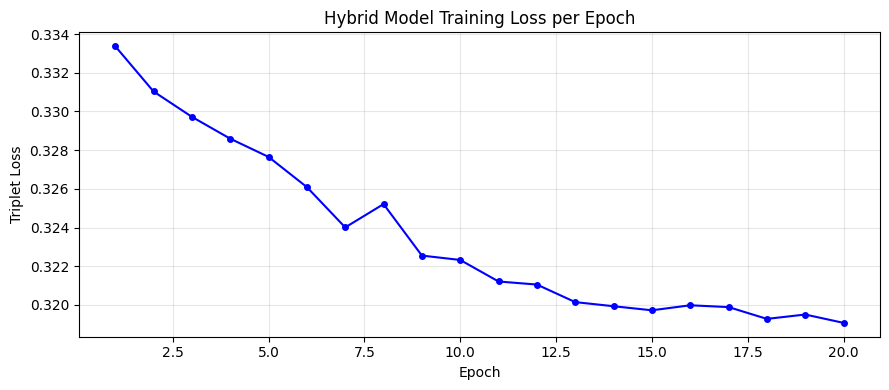

Grafik disimpan: results/training_loss_hybrid.png


In [11]:
plt.figure(figsize=(9, 4))
plt.plot(range(1, len(train_losses) + 1), train_losses, 'b-o', markersize=4)
plt.title('Hybrid Model Training Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Triplet Loss')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{BASE_OUT}/results/bab4/training_loss_hybrid.png', dpi=150)
plt.show()
print('Grafik disimpan: results/training_loss_hybrid.png')

## Cell 13 — Fungsi Evaluasi Universal

In [12]:
def average_precision(rel):
    if rel.sum()==0: return 0.0
    p, n = [], 0
    for i, r in enumerate(rel,1):
        if r: n+=1; p.append(n/i)
    return float(np.mean(p))

def ndcg_at_k(rel, k):
    dcg  = sum(r/np.log2(i+2) for i,r in enumerate(rel[:k]))
    idcg = sum(1/np.log2(i+2) for i in range(min(int(rel.sum()),k)))
    return dcg/idcg if idcg>0 else 0.0

@torch.no_grad()
def evaluate_on_metu(embed_fn, query_dir, k=TOP_K, hsv_fn=None, alpha=ALPHA_FUSION):
    paths  = sorted(Path(query_dir).glob('*.jpg'))
    groups = np.array([p.stem.split('-')[-1] for p in paths])
    
    # Ekstrak embedding utama
    embeds = np.stack([embed_fn(p) for p in tqdm(paths, desc='Embedding query')])
    sims   = cosine_similarity(embeds, embeds)
    
    # Jika ada hsv_fn, hitung color similarity dan late fusion
    if hsv_fn is not None:
        hsv_vecs = np.stack([hsv_fn(p) for p in tqdm(paths, desc='HSV query')])
        color_sims = cosine_similarity(hsv_vecs, hsv_vecs)
        sims = alpha * sims + (1 - alpha) * color_sims  # late fusion

    np.fill_diagonal(sims, -1)

    all_ap, all_p, all_r, all_ndcg = [], [], [], []
    for i in range(len(groups)):
        order = np.argsort(sims[i])[::-1][:k]
        rel   = (groups[order] == groups[i]).astype(int)
        total = max((groups == groups[i]).sum() - 1, 1)
        all_ap.append(average_precision(rel))
        all_p.append(rel[:k].mean())
        all_r.append(rel[:k].sum() / total)
        all_ndcg.append(ndcg_at_k(rel, k))

    return {'mAP': float(np.mean(all_ap)), f'P@{k}': float(np.mean(all_p)),
            f'R@{k}': float(np.mean(all_r)), f'nDCG@{k}': float(np.mean(all_ndcg))}

print('Fungsi evaluasi siap.')

Fungsi evaluasi siap.


## Cell 14 — Baseline Comparison 4 Skenario (Tabel Resmi Bab 4)

In [13]:
# Load model terbaik
ckpt = torch.load(HYBRID_CKPT_PATH, map_location=DEVICE)
model.load_state_dict(ckpt['model_state'])
model.eval()
print(f'Model terbaik dimuat dari epoch {ckpt["epoch"]}')

# ---- SKENARIO 1: Pretrained Only (Baseline) ----
class BaselineModel(nn.Module):
    def __init__(self):
        super().__init__()
        eff = models.efficientnet_v2_s(weights='IMAGENET1K_V1')
        self.backbone = nn.Sequential(*list(eff.children())[:-1])
        self.pool = nn.AdaptiveAvgPool2d(1)
        for p in self.backbone.parameters(): p.requires_grad=False
    def forward(self, img):
        f = self.backbone(img); f = self.pool(f).flatten(1)
        return nn.functional.normalize(f, p=2, dim=1)

baseline_model = BaselineModel().to(DEVICE).eval()

@torch.no_grad()
def embed_baseline(p):
    img = Image.open(p).convert('RGB')
    t = tf_eff_val(img).unsqueeze(0).to(DEVICE)
    return baseline_model(t).cpu().numpy().flatten()

# ---- SKENARIO 2: Handcrafted Only (HOG + HSV, tanpa deep learning) ----
def embed_handcrafted(p):
    img = Image.open(p).convert('RGB')
    t = tf_hc_val(img)
    h = extract_hog(t)
    c = extract_hsv_histogram(t)
    combined = np.concatenate([h/np.linalg.norm(h+1e-8), c/np.linalg.norm(c+1e-8)])
    return combined / (np.linalg.norm(combined) + 1e-8)

# ---- SKENARIO 3 & 4: Hybrid ----
@torch.no_grad()
def embed_hybrid(p):
    img = Image.open(p).convert('RGB')
    t_eff = tf_eff_val(img).unsqueeze(0).to(DEVICE)
    t_hc  = tf_hc_val(img)
    hog_v = torch.tensor(extract_hog(t_hc), dtype=torch.float32).unsqueeze(0).to(DEVICE)
    return model(t_eff, hog_v).cpu().numpy().flatten()

def extract_hsv_from_path(p):
    img = Image.open(p).convert('RGB')
    return extract_hsv_histogram(tf_hc_val(img))

# ====================================================================
# EVALUASI 4 SKENARIO
# ====================================================================
results_comparison = {}

print('Skenario 1: Pretrained Only (Baseline)...')
results_comparison['Pretrained Only (Baseline)'] = evaluate_on_metu(
    embed_baseline, METU_QUERY_DIR
    # Tanpa hsv_fn -- murni deep learning pretrained
)

print('Skenario 2: Handcrafted Only (HOG + HSV)...')
results_comparison['Handcrafted Only (HOG+HSV)'] = evaluate_on_metu(
    embed_handcrafted, METU_QUERY_DIR
    # Tanpa hsv_fn -- HSV sudah masuk di dalam embed_handcrafted
)

print('Skenario 3: Hybrid Early Fusion (EfficientNet + HOG, tanpa HSV)...')
results_comparison['Hybrid Early Fusion (α=1.0)'] = evaluate_on_metu(
    embed_hybrid, METU_QUERY_DIR,
    hsv_fn=None,   # ← TANPA late fusion HSV
    alpha=1.0
)

print('Skenario 4: Hybrid Full (Early Fusion + Late Fusion HSV, α=0.9)...')
results_comparison['Hybrid Full (α=0.9)'] = evaluate_on_metu(
    embed_hybrid, METU_QUERY_DIR,
    hsv_fn=extract_hsv_from_path,  # ← DENGAN late fusion HSV
    alpha=0.9
)

# Tampilkan hasil
df_comparison = pd.DataFrame(results_comparison).T.round(4)
print('\n' + '='*70)
print('BASELINE COMPARISON — HASIL UNTUK BAB 4')
print('='*70)
print(df_comparison.to_string())
print('='*70)

best_scenario = df_comparison['mAP'].idxmax()
print(f'\nSkenario terbaik   : {best_scenario}')
print(f'mAP terbaik        : {df_comparison.loc[best_scenario, "mAP"]:.4f}')
print(f'\nKonfigurasi FINAL sistem (dipilih berdasarkan evaluasi):')
print(f'  → Hybrid Early Fusion α=1.0 (mAP={df_comparison.loc["Hybrid Early Fusion (α=1.0)","mAP"]:.4f})')
print(f'  → Penambahan HSV late fusion (α=0.9) tidak meningkatkan performa')
print(f'    (mAP={df_comparison.loc["Hybrid Full (α=0.9)","mAP"]:.4f}) — dikonfirmasi dengan alpha sweep')

Model terbaik dimuat dari epoch 20
Skenario 1: Pretrained Only (Baseline)...


Embedding query: 100%|██████████| 417/417 [00:14<00:00, 29.77it/s]


Skenario 2: Handcrafted Only (HOG + HSV)...


Embedding query: 100%|██████████| 417/417 [00:09<00:00, 42.04it/s]


Skenario 3: Hybrid Early Fusion (EfficientNet + HOG, tanpa HSV)...


Embedding query: 100%|██████████| 417/417 [00:18<00:00, 22.25it/s]


Skenario 4: Hybrid Full (Early Fusion + Late Fusion HSV, α=0.9)...


HSV query: 100%|██████████| 417/417 [00:02<00:00, 163.35it/s]



BASELINE COMPARISON — HASIL UNTUK BAB 4
                                mAP    P@10    R@10  nDCG@10
Pretrained Only (Baseline)   0.6981  0.4058  0.3716   0.7805
Handcrafted Only (HOG+HSV)   0.4796  0.1959  0.1780   0.5517
Hybrid Early Fusion (α=1.0)  0.6898  0.3914  0.3546   0.7802
Hybrid Full (α=0.9)          0.6764  0.3746  0.3398   0.7647

Skenario terbaik   : Pretrained Only (Baseline)
mAP terbaik        : 0.6981

Konfigurasi FINAL sistem (dipilih berdasarkan evaluasi):
  → Hybrid Early Fusion α=1.0 (mAP=0.6898)
  → Penambahan HSV late fusion (α=0.9) tidak meningkatkan performa
    (mAP=0.6764) — dikonfirmasi dengan alpha sweep


## Cell 15 — Simpan Tabel Baseline Comparison

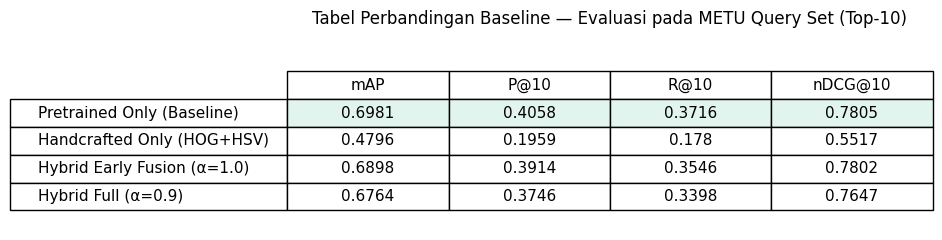

Tabel tersimpan di results/bab4/


In [14]:
# Simpan sebagai CSV
df_comparison.to_csv(f'{BASE_OUT}/results/bab4/baseline_comparison.csv')

# Simpan sebagai gambar tabel
fig, ax = plt.subplots(figsize=(10, 2.5))
ax.axis('off')
table = ax.table(cellText=df_comparison.values, rowLabels=df_comparison.index,
                  colLabels=df_comparison.columns, cellLoc='center', loc='center')
table.auto_set_font_size(False); table.set_fontsize(11); table.scale(1.2, 1.8)

# 1. Cari nama index (model) yang memiliki nilai mAP paling tinggi
best_model_name = df_comparison['mAP'].idxmax()

# 2. Dapatkan posisi barisnya di dalam tabel matplotlib (ditambah 1 karena ada baris header)
best_row_idx = list(df_comparison.index).index(best_model_name) + 1

# 3. Warnai seluruh kolom pada baris terbaik tersebut
for col in range(len(df_comparison.columns)):
    table[best_row_idx, col].set_facecolor('#E1F5EE') # Warna hijau muda estetik

plt.title('Tabel Perbandingan Baseline — Evaluasi pada METU Query Set (Top-10)', pad=20)
plt.tight_layout()
plt.savefig(f'{BASE_OUT}/results/bab4/tabel_baseline_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Simpan juga sebagai JSON
with open(f'{BASE_OUT}/results/bab4/baseline_comparison.json', 'w') as f:
    json.dump(results_comparison, f, indent=2)

print('Tabel tersimpan di results/bab4/')

## Cell 16 — Alpha Sweep (Penentuan α Optimal)

Alpha sweep...


HSV query: 100%|██████████| 417/417 [00:02<00:00, 166.87it/s]


  α=0.5 | mAP=0.6028


HSV query: 100%|██████████| 417/417 [00:02<00:00, 166.91it/s]


  α=0.6 | mAP=0.6261


...

  α=0.8 | mAP=0.6518


HSV query: 100%|██████████| 417/417 [00:02<00:00, 165.32it/s]


  α=0.9 | mAP=0.6764


HSV query: 100%|██████████| 417/417 [00:02<00:00, 164.45it/s]


  α=1.0 | mAP=0.6898

Alpha terbaik: 1.0 (mAP=0.6898)


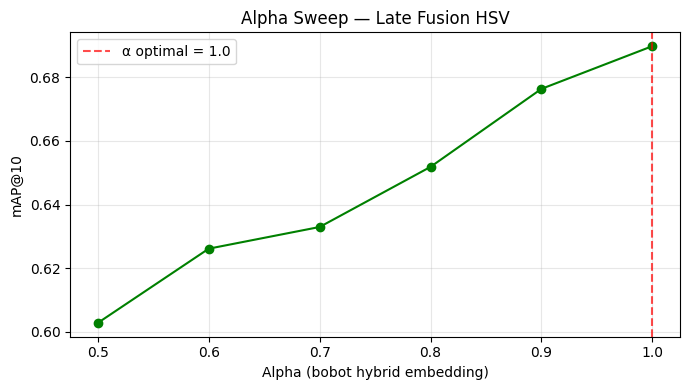

Grafik disimpan: results/bab4/alpha_sweep.png


In [15]:
@torch.no_grad()
def embed_hybrid_for_sweep(p):
    img   = Image.open(p).convert('RGB')
    t_eff = tf_eff_val(img).unsqueeze(0).to(DEVICE)
    t_hc  = tf_hc_val(img)
    hog_v = torch.tensor(extract_hog(t_hc), dtype=torch.float32).unsqueeze(0).to(DEVICE)
    return model(t_eff, hog_v).cpu().numpy().flatten()

def hsv_from_path(p):
    img = Image.open(p).convert('RGB')
    return extract_hsv_histogram(tf_hc_val(img))

alphas     = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
alpha_maps = []

print('Alpha sweep...')
for a in alphas:
    res = evaluate_on_metu(
        embed_hybrid_for_sweep, METU_QUERY_DIR,
        hsv_fn=hsv_from_path, alpha=a
    )
    alpha_maps.append(res['mAP'])
    print(f'  α={a:.1f} | mAP={res["mAP"]:.4f}')

best_alpha = alphas[int(np.argmax(alpha_maps))]
print(f'\nAlpha terbaik: {best_alpha} (mAP={max(alpha_maps):.4f})')

plt.figure(figsize=(7, 4))
plt.plot(alphas, alpha_maps, 'g-o', markersize=6)
plt.axvline(x=best_alpha, color='red', linestyle='--',
            alpha=0.7, label=f'α optimal = {best_alpha}')
plt.title('Alpha Sweep — Late Fusion HSV')
plt.xlabel('Alpha (bobot hybrid embedding)')
plt.ylabel('mAP@10')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(f'{BASE_OUT}/results/bab4/alpha_sweep.png', dpi=150)
plt.show()
print('Grafik disimpan: results/bab4/alpha_sweep.png')

## Cell 17 — Build Embedding Database PDKI

In [99]:
@torch.no_grad()
def build_pdki_database(pdki_dir, model):
    pdki_root = Path(pdki_dir)

    # ===================== STEP 1: BACA SEMUA CSV DENGAN COMPOSITE KEY =====================
    all_csv = list(pdki_root.rglob('*.csv'))
    print(f'Ditemukan {len(all_csv)} file CSV')

    # Dict: (folder_key, image_filename) -> metadata row
    # Contoh key: ('kelas1_2025', 'image_2.jpg')
    meta_lookup = {}

    for csv_path in all_csv:
        try:
            df = pd.read_csv(csv_path)
            # Skip CSV yang bukan metadata logo
            if 'application_id' not in df.columns:
                print(f'  Skip {csv_path.name} (bukan metadata logo)')
                continue

            # Nama file CSV = nama folder (kelas1_2025.csv -> kelas1_2025)
            folder_key = csv_path.stem  # 'kelas1_2025'

            for _, row in df.iterrows():
                img_filename = Path(str(row.get('image_filename', ''))).name
                if img_filename:
                    composite_key = (folder_key, img_filename)
                    meta_lookup[composite_key] = row.to_dict()

        except Exception as e:
            print(f'  Error baca {csv_path.name}: {e}')

    print(f'Total entri metadata: {len(meta_lookup)}')

    # ===================== STEP 2: VALIDASI FILE GAMBAR =====================
    all_paths = sorted(
        list(pdki_root.rglob('*.jpg')) +
        list(pdki_root.rglob('*.png'))
    )
    valid_paths = []
    for p in all_paths:
        try:
            Image.open(p).verify()
            valid_paths.append(p)
        except:
            continue
    print(f'Total logo PDKI valid: {len(valid_paths)}')

    # ===================== STEP 3: EKSTRAK EMBEDDING + METADATA =====================
    all_embeds, all_hsv, all_meta = [], [], []
    n_matched = 0

    model.eval()
    for p in tqdm(valid_paths, desc='Build PDKI database'):
        try:
            img   = Image.open(p).convert('RGB')
            t_eff = tf_eff_val(img).unsqueeze(0).to(DEVICE)
            t_hc  = tf_hc_val(img)
            hog_v = torch.tensor(
                extract_hog(t_hc), dtype=torch.float32
            ).unsqueeze(0).to(DEVICE)
            hsv_v = extract_hsv_histogram(t_hc)
            emb   = model(t_eff, hog_v).cpu().numpy().flatten()

            all_embeds.append(emb)
            all_hsv.append(hsv_v)

            # Buat composite key dari path gambar
            # p = .../kelas1_2025/images/image_2.jpg
            # folder_key = 'kelas1_2025' (parent dari folder 'images')
            folder_key   = p.parent.parent.name  # kelas1_2025
            img_filename = p.name                # image_2.jpg
            composite_key = (folder_key, img_filename)

            # Base metadata (fallback)
            entry = {
                'path'              : str(p),
                'filename'          : img_filename,
                'brand'             : folder_key,
                'application_id'    : '',
                'nomor_permohonan'  : '',
                'nama_merek'        : folder_key,
                'kelas_nice'        : '',
                'tahun'             : '',
                'tanggal_permohonan': '',
                'status_permohonan' : 'N/A',
                'owner_name'        : '',
                'class_desc'        : '',
            }

            # Match ke metadata CSV
            if composite_key in meta_lookup:
                row = meta_lookup[composite_key]
                entry.update({
                    'application_id'    : str(row.get('application_id', '')),
                    'nomor_permohonan'  : str(row.get('nomor_permohonan', '')),
                    'nama_merek'        : str(row.get('nama_merek', folder_key))[:50],
                    'kelas_nice'        : str(row.get('kelas_nice', '')),
                    'tahun'             : str(row.get('tahun', '')),
                    'tanggal_permohonan': str(row.get('tanggal_permohonan', '')),
                    'status_permohonan' : str(row.get('status_permohonan', 'N/A')),
                    'owner_name'        : str(row.get('owner_name', ''))[:50],
                    'class_desc'        : str(row.get('class_desc', ''))[:100],
                })
                n_matched += 1

            all_meta.append(entry)

        except Exception:
            continue

    # ===================== STEP 4: SIMPAN =====================
    db_embeds = np.stack(all_embeds)
    db_hsv    = np.stack(all_hsv)

    np.save(f'{BASE_OUT}/models/pdki_embeddings.npy', db_embeds)
    np.save(f'{BASE_OUT}/models/pdki_hsv.npy', db_hsv)
    with open(f'{BASE_OUT}/models/pdki_metadata.json', 'w', encoding='utf-8') as f:
        json.dump(all_meta, f, indent=2, ensure_ascii=False)

    print(f'\nDatabase tersimpan:')
    print(f'  Embedding : {db_embeds.shape}')
    print(f'  Metadata  : {len(all_meta)} entri')
    print(f'  Match CSV : {n_matched}/{len(valid_paths)} logo ({n_matched/len(valid_paths)*100:.1f}%)')

    # Distribusi status
    from collections import Counter
    statuses = [m['status_permohonan'] for m in all_meta]
    print('\nDistribusi status di database final:')
    for status, count in Counter(statuses).most_common():
        print(f'  {status}: {count} logo')

    return db_embeds, db_hsv, all_meta


# Jalankan
db_embeds, db_hsv, db_meta = build_pdki_database(PDKI_DIR, model)

Ditemukan 136 file CSV
  Skip batch_summary.csv (bukan metadata logo)
Total entri metadata: 6698
Total logo PDKI valid: 6698


Build PDKI database: 100%|██████████| 6698/6698 [05:59<00:00, 18.65it/s]



Database tersimpan:
  Embedding : (6698, 256)
  Metadata  : 6698 entri
  Match CSV : 6698/6698 logo (100.0%)

Distribusi status di database final:
  (TM) Didaftar: 3716 logo
  (TM) Masa Pengumuman (BRM): 1854 logo
  (TM) Pemeriksaan Substantif: 533 logo
  (TM) Ditolak: 524 logo
  (TM) Selesai Masa Pengumuman: 24 logo
  (TM) Ditarik Kembali: 23 logo
  (TM) Ditolak Karena Tidak Ada Tanggapan (TAT): 7 logo
  (TM) Persetujuan Direktur untuk diberi: 5 logo
  (TM) Dalam Proses Persidangan KBM: 3 logo
  (TM) Pengadilan: 2 logo
  (TM) Masa Pengumuman: 2 logo
  (TM) Pemeriksaan Formalitas Banding Merek: 2 logo
  (M) Inactive: 1 logo
  (TM) Usulan Tanggapan Diterima: 1 logo
  (TM) Ditolak KBM: 1 logo


## Cell 18 — Visualisasi Preprocessing (Sebelum vs Sesudah)

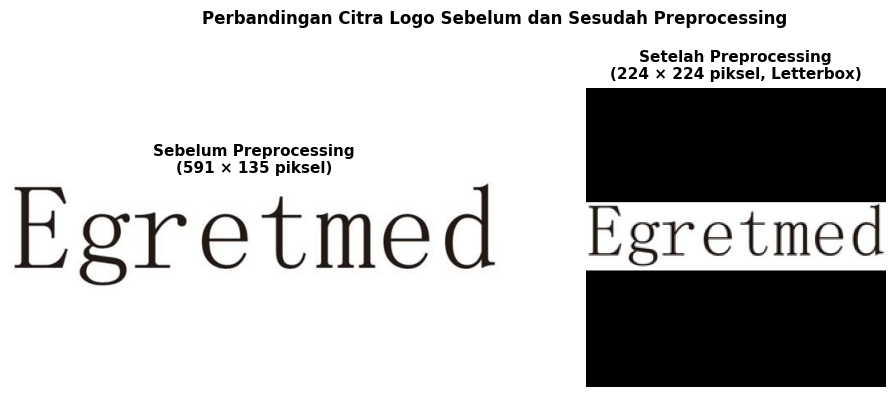

Ukuran asli: 591 x 135


In [105]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import torchvision.transforms as T
import numpy as np

# Pilih satu logo yang menarik untuk contoh
# Idealnya logo horizontal (word mark) agar efek letterbox terlihat jelas
sample_path = db_meta[0]['path']  # atau pilih logo tertentu
img_asli = Image.open(sample_path).convert('RGB')

# Terapkan letterbox resize
img_preprocessed = tf_hc_val(img_asli)  # tensor
img_preprocessed_pil = T.ToPILImage()(img_preprocessed)

# Visualisasi berdampingan
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Sebelum
axes[0].imshow(img_asli)
axes[0].set_title(f'Sebelum Preprocessing\n({img_asli.width} × {img_asli.height} piksel)',
                   fontsize=11, fontweight='bold')
axes[0].axis('off')

# Sesudah
axes[1].imshow(img_preprocessed_pil)
axes[1].set_title(f'Setelah Preprocessing\n(224 × 224 piksel, Letterbox)',
                   fontsize=11, fontweight='bold')
axes[1].axis('off')

plt.suptitle('Perbandingan Citra Logo Sebelum dan Sesudah Preprocessing',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{BASE_OUT}/results/bab4/preprocessing_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(f'Ukuran asli: {img_asli.width} x {img_asli.height}')

## Cell 19 — Demo Retrieval + Late Fusion

Demo retrieval pada 3 logo PDKI acak...


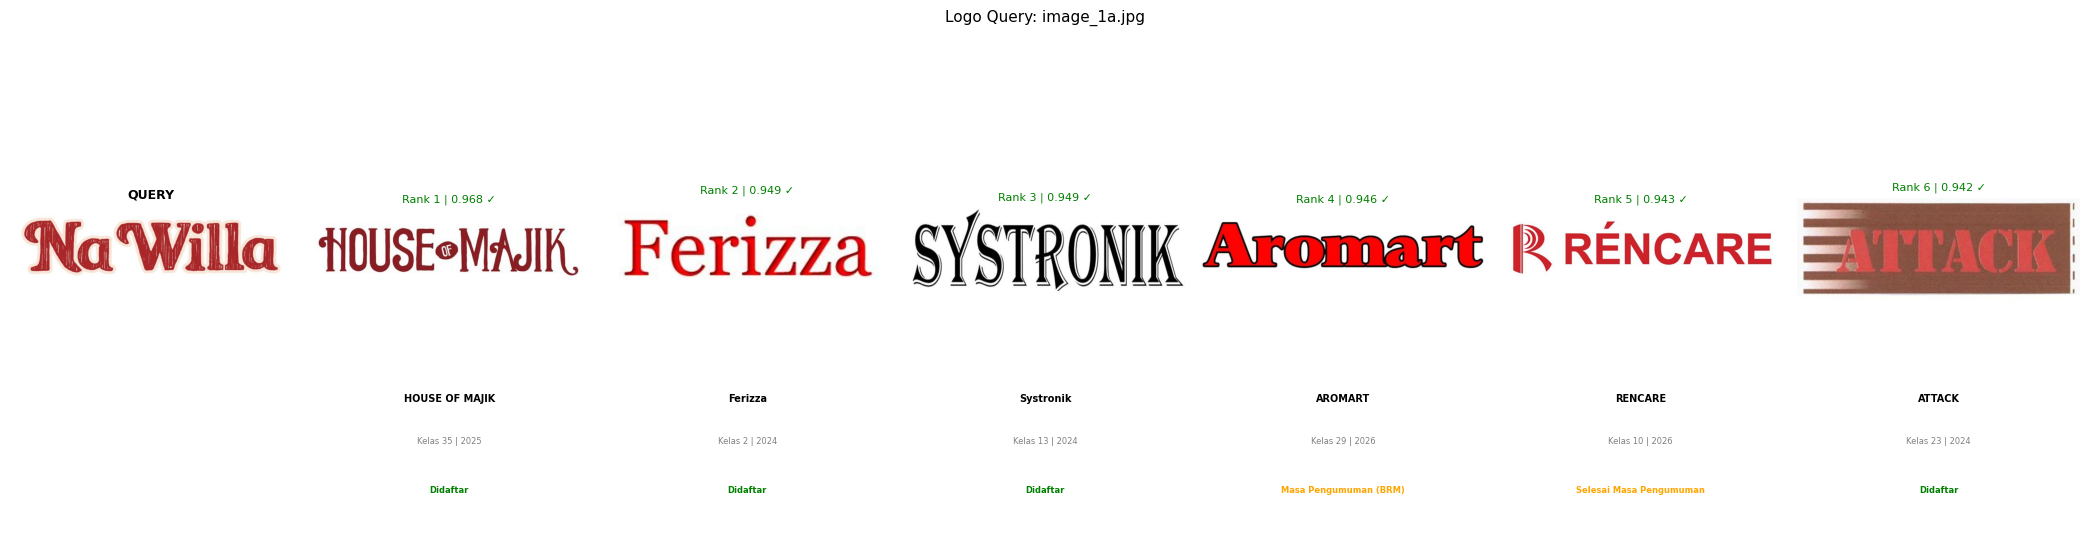

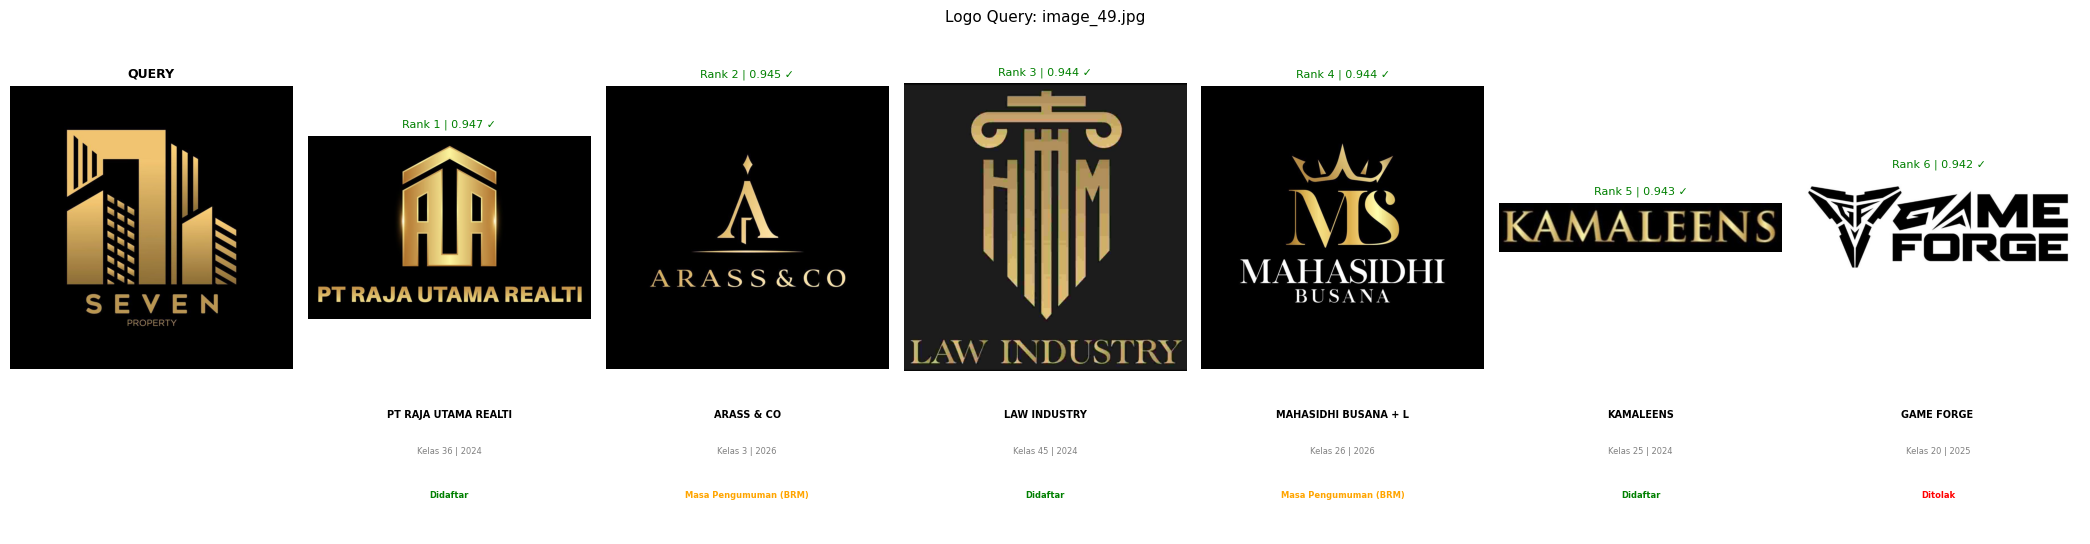

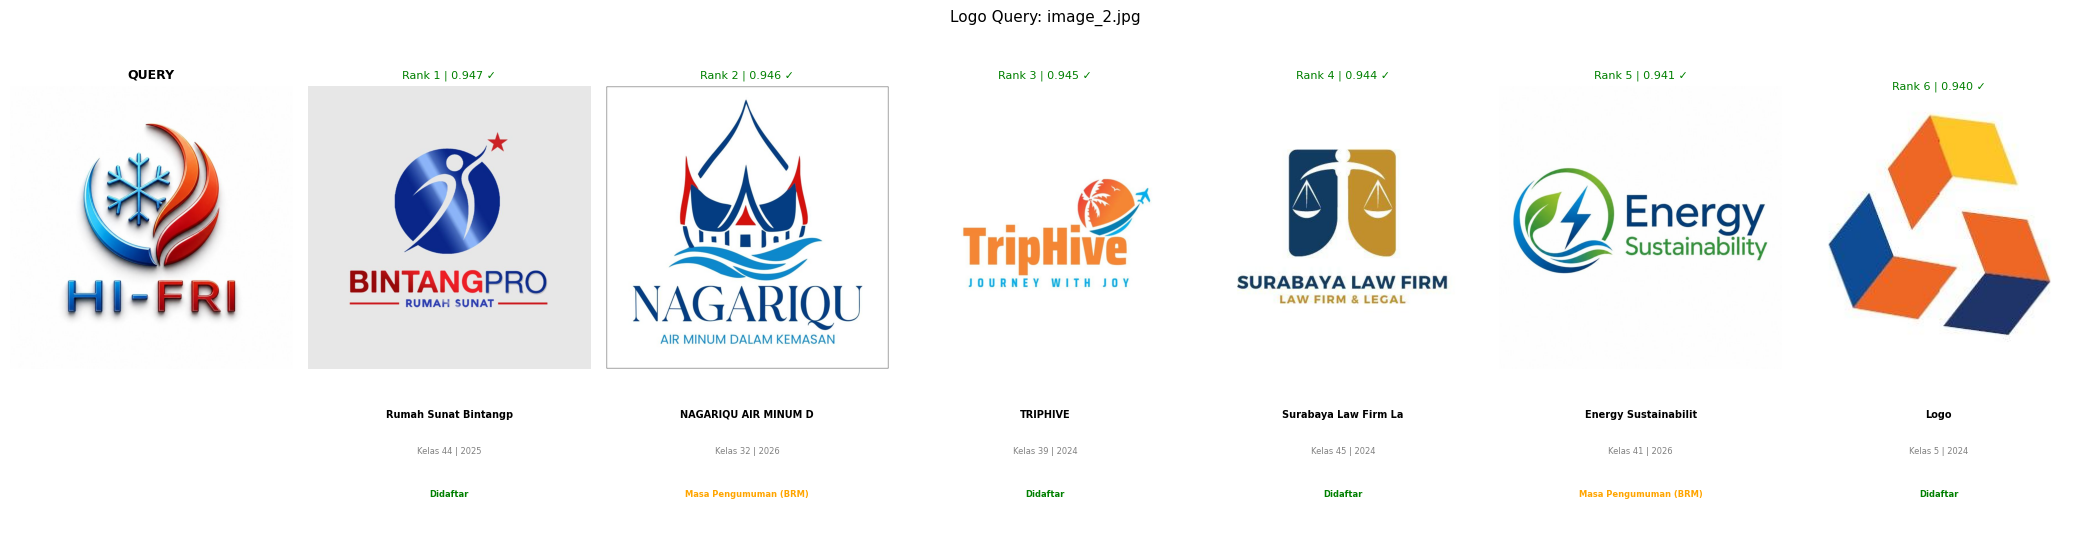

In [111]:
def retrieve_topk(query_path, db_embeds, db_hsv, db_meta,
                   k=TOP_K, alpha=ALPHA_FUSION, threshold=0.5):
    img = Image.open(query_path).convert('RGB')
    t_eff = tf_eff_val(img).unsqueeze(0).to(DEVICE)
    t_hc  = tf_hc_val(img)
    hog_v = torch.tensor(extract_hog(t_hc), dtype=torch.float32).unsqueeze(0).to(DEVICE)
    hsv_q = extract_hsv_histogram(t_hc)

    with torch.no_grad():
        emb_q = model(t_eff, hog_v).cpu().numpy().flatten()

    hybrid_scores = cosine_similarity(emb_q.reshape(1,-1), db_embeds).flatten()
    color_scores  = cosine_similarity(hsv_q.reshape(1,-1), db_hsv).flatten()
    final_scores  = alpha * hybrid_scores + (1-alpha) * color_scores

    # ← TAMBAHKAN INI: exclude query dari hasil kalau ada di database
    query_abs = os.path.abspath(str(query_path))
    for j, meta in enumerate(db_meta):
        if os.path.abspath(str(meta['path'])) == query_abs:
            final_scores[j] = -999  # paksa ke bawah ranking
            break

    top_k_idx    = np.argsort(final_scores)[::-1][:k]
    top_k_scores = final_scores[top_k_idx]
    is_similar   = top_k_scores >= threshold

    return top_k_idx, top_k_scores, is_similar


def visualize_retrieval(query_path, top_k_idx, top_k_scores, 
                         is_similar, db_meta, save_path=None):
    n_show = min(6, len(top_k_idx))
    fig, axes = plt.subplots(2, n_show+1,
                              figsize=(3*(n_show+1), 5.5),
                              gridspec_kw={'height_ratios': [3, 1.2]})

    # Query
    axes[0][0].imshow(Image.open(query_path).convert('RGB'))
    axes[0][0].set_title('QUERY', fontweight='bold', fontsize=9)
    axes[0][0].axis('off')
    axes[1][0].axis('off')

    for rank, (idx, score, sim) in enumerate(
        zip(top_k_idx[:n_show], top_k_scores[:n_show], is_similar[:n_show]), 1
    ):
        meta  = db_meta[idx]
        color = 'green' if sim else 'red'

        # Gambar kandidat
        try:
            axes[0][rank].imshow(Image.open(meta['path']).convert('RGB'))
        except:
            axes[0][rank].text(0.5, 0.5, 'Error', ha='center',
                                transform=axes[0][rank].transAxes)

        axes[0][rank].set_title(
            f'Rank {rank} | {score:.3f} {"✓" if sim else "✗"}',
            fontsize=8, color=color
        )
        axes[0][rank].axis('off')

        # Info metadata di bawah gambar
        nama   = meta.get('nama_merek', 'N/A')[:20]
        status = meta.get('status_permohonan', 'N/A')
        kelas  = meta.get('kelas_nice', '')
        tahun  = meta.get('tahun', '')

        # Warna berdasarkan status
        if 'didaftar' in status.lower():
            sc = 'green'
        elif 'tolak' in status.lower():
            sc = 'red'
        elif 'pengumuman' in status.lower() or 'substantif' in status.lower():
            sc = 'orange'
        else:
            sc = 'gray'

        axes[1][rank].text(0.5, 0.85, nama, ha='center', va='top',
                            fontsize=7, fontweight='bold',
                            transform=axes[1][rank].transAxes)
        axes[1][rank].text(0.5, 0.55, f'Kelas {kelas} | {tahun}',
                            ha='center', fontsize=6, color='gray',
                            transform=axes[1][rank].transAxes)
        axes[1][rank].text(0.5, 0.25, status.replace('(TM) ', ''),
                            ha='center', fontsize=6, color=sc,
                            fontweight='bold',
                            transform=axes[1][rank].transAxes)
        axes[1][rank].axis('off')

    plt.suptitle(f'Logo Query: {Path(query_path).name}', fontsize=11)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=120, bbox_inches='tight')
    plt.show()


# Demo dengan 3 sampel query dari PDKI
print('Demo retrieval pada 3 logo PDKI acak...')
sample_paths = [db_meta[i]['path'] for i in np.random.choice(len(db_meta), 3, replace=False)]
for i, qpath in enumerate(sample_paths):
    idx, scores, sim = retrieve_topk(qpath, db_embeds, db_hsv, db_meta)
    visualize_retrieval(qpath, idx, scores, sim, db_meta,
                         save_path=f'{BASE_OUT}/results/bab4/retrieval_demo3_{i+1}.png')

## Cell 20 — EigenGradCAM (XAI)

Generating Grad-CAM++ v2 (EigenGradCAM)...


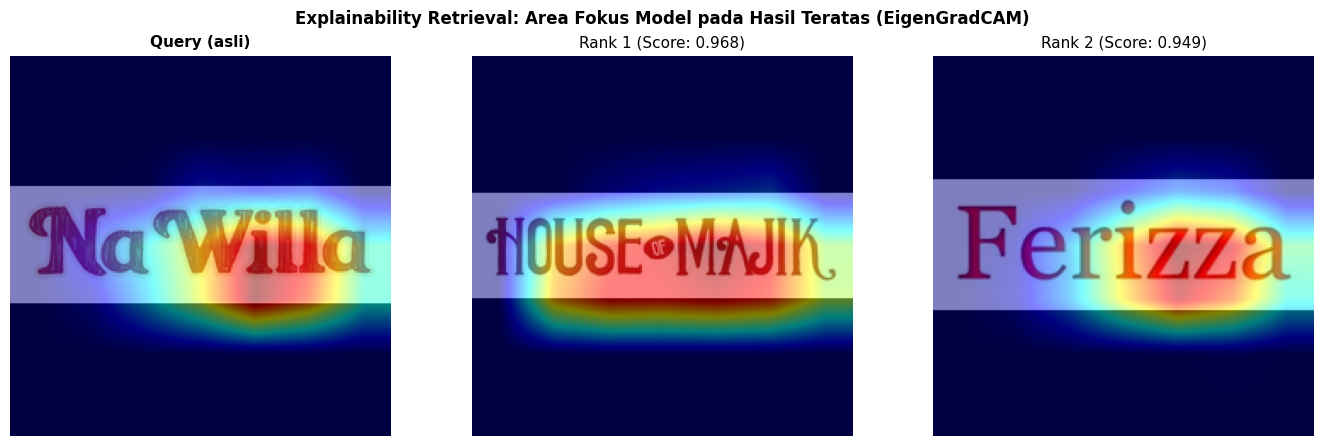

Brightness gambar query asli: 0.253
Heatmap range (Rank terakhir): min=0.0000, max=1.0000


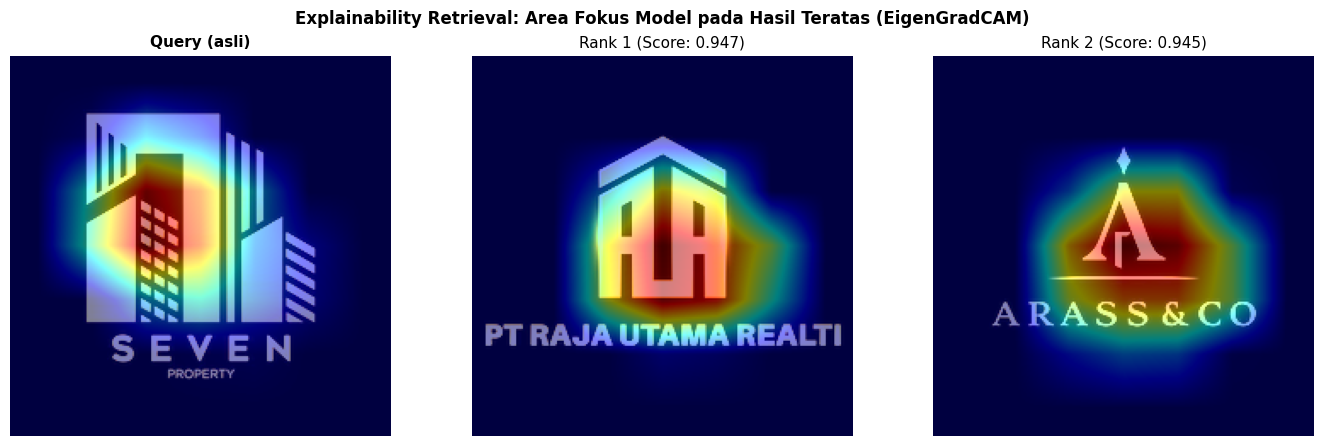

Brightness gambar query asli: 0.119
Heatmap range (Rank terakhir): min=0.0000, max=1.0000


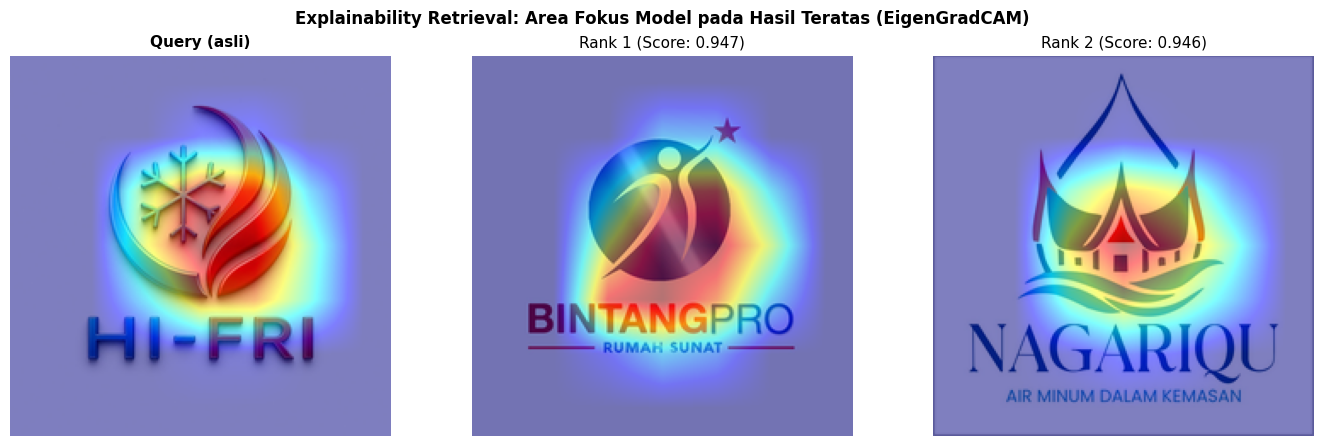

Brightness gambar query asli: 0.898
Heatmap range (Rank terakhir): min=0.0000, max=1.0000

✅ [SUKSES] Semua file Grad-CAM berbasis database PDKI berhasil disimpan di results/bab4/


In [112]:
from pytorch_grad_cam import GradCAMPlusPlus, EigenGradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from PIL import Image
import cv2
import os 

# Pastikan model utama dalam keadaan siap
model.eval()

class ModelWrapperForCAM(nn.Module):
    def __init__(self, model, hog_vec_fixed, ref_embedding=None):
        super().__init__()
        self.model = model
        self.hog_fixed = hog_vec_fixed
        # ref_embedding = embedding kandidat Rank-1 (numpy array atau tensor)
        self.ref = torch.tensor(ref_embedding, dtype=torch.float32) \
                   if ref_embedding is not None else None

    def forward(self, img):
        emb = self.model(img, self.hog_fixed)
        if self.ref is not None:
            # Dot product antara query dan kandidat Rank-1
            # = cosine similarity karena embedding sudah L2-normalized
            return (emb * self.ref.to(emb.device)).sum(dim=1, keepdim=True)
        else:
            # Fallback ke L2 norm kalau tidak ada referensi
            return emb.norm(dim=1, keepdim=True)


def generate_gradcam_v2(query_path, ref_embedding=None, save_path=None, use_eigen=True):
    """
    Grad-CAM++ yang mengambil hasil pencarian nyata dari database,
    dan otomatis menampilkan visualisasi untuk Query, Rank Terdekat 1, dan Rank Terdekat 2.
    """
    # 1. Jalankan pencarian Top-K (ambil k=4 sebagai cadangan)
    top_k_idx, top_k_scores, is_similar = retrieve_topk(query_path, db_embeds, db_hsv, db_meta, k=4)
    
    filtered_paths = []
    filtered_titles = []
    
    # Gambar pertama di kolom kiri WAJIB Query Asli
    filtered_paths.append(query_path)
    filtered_titles.append("Query (asli)")
    
    # Ambil hasil tetangga terdekat berikutnya yang path-nya tidak sama persis dengan query
    rank_counter = 1
    for idx, score in zip(top_k_idx, top_k_scores):
        candidate_path = db_meta[idx]['path']
        if os.path.abspath(candidate_path) != os.path.abspath(query_path):
            filtered_paths.append(candidate_path)
            filtered_titles.append(f'Rank {rank_counter} (Score: {score:.3f})')
            rank_counter += 1
        if len(filtered_paths) == 3: 
            break

    # Antisipasi jika database kosong
    while len(filtered_paths) < 3:
        filtered_paths.append(query_path)
        filtered_titles.append("N/A")

    # --- 2. MULAI PROSES GRAD-CAM PADA 3 GAMBAR BERBEDA ---
    fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
    CAMClass = EigenGradCAM if use_eigen else GradCAMPlusPlus
    target_layer = [model.backbone[0][-1]]

    last_brightness = 0.0
    last_min_cam, last_max_cam = 0.0, 0.0

    for col in range(3):
        current_path = filtered_paths[col]
        img_pil = Image.open(current_path).convert('RGB')
        
        t_eff = tf_eff_val(img_pil).unsqueeze(0).to(DEVICE)
        t_hc  = tf_hc_val(img_pil)
        hog_v = torch.tensor(extract_hog(t_hc), dtype=torch.float32).unsqueeze(0).to(DEVICE)

        # Bungkus model secara lokal untuk ekstraksi gradien kolom aktif
        wrapped = ModelWrapperForCAM(model, hog_v, ref_embedding)  # dengan ref
        wrapped.eval() 
        for p in wrapped.parameters():
            p.requires_grad_(True)

        with CAMClass(model=wrapped, target_layers=target_layer) as cam:
            grayscale_cam = cam(input_tensor=t_eff, targets=None)[0]

        last_min_cam, last_max_cam = grayscale_cam.min(), grayscale_cam.max()

        mean = np.array([0.485, 0.456, 0.406])
        std  = np.array([0.229, 0.224, 0.225])
        img_np = t_eff.squeeze().permute(1,2,0).cpu().numpy()
        img_np = (img_np * std + mean).clip(0, 1).astype(np.float32)

        current_brightness = img_np.mean()
        if col == 0:
            last_brightness = current_brightness

        if current_brightness < 0.2: 
            img_np_bright = np.clip(img_np * 3.0, 0, 1)
        else:
            img_np_bright = img_np

        cam_overlay = show_cam_on_image(img_np_bright, grayscale_cam, use_rgb=True)

        axes[col].imshow(cam_overlay)
        axes[col].set_title(filtered_titles[col], fontsize=11, fontweight='bold' if col==0 else 'normal')
        axes[col].axis('off')

    cam_type = 'EigenGradCAM' if use_eigen else 'GradCAM++'
    plt.suptitle(f'Explainability Retrieval: Area Fokus Model pada Hasil Teratas ({cam_type})', fontsize=12, fontweight='bold')
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

    print(f'Brightness gambar query asli: {last_brightness:.3f}')
    print(f'Heatmap range (Rank terakhir): min={last_min_cam:.4f}, max={last_max_cam:.4f}')


# ===================== UBAH BAGIAN INI AGAR TERHUBUNG KE DEMO =====================
os.makedirs(f'{BASE_OUT}/results/bab4', exist_ok=True)

print('Generating Grad-CAM++ v2 (EigenGradCAM)...')
print('='*60)

# Langsung mengambil data dari sample_paths yang dieksekusi pada cell demo pencarian sebelumnya
# Untuk tiap query, ambil dulu Rank-1 dari retrieval
for i, qpath in enumerate(sample_paths):
    # Jalankan retrieval dulu
    top_idx, top_scores, top_sim = retrieve_topk(
        qpath, db_embeds, db_hsv, db_meta
    )

    # Ambil embedding kandidat Rank-1 sebagai referensi
    ref_emb = db_embeds[top_idx[0]]  # numpy array 256-dim

    # Generate Grad-CAM dengan referensi Rank-1
    generate_gradcam_v2(
        qpath,
        ref_embedding=ref_emb,        # ← ini yang baru
        save_path=f'{BASE_OUT}/results/bab4/gradcam_{i+1}.png',
        use_eigen=True
    )
print('\n✅ [SUKSES] Semua file Grad-CAM berbasis database PDKI berhasil disimpan di results/bab4/')

## Cell 20B — Occlusion Sensitivity (XAI Utama)

Occlusion Sensitivity menjelaskan **skor fusion akhir** secara langsung — berbeda dengan EigenGradCAM yang hanya menjelaskan cabang CNN.

**Cara kerja:**
- Area logo query ditutup (patch) secara sistematis
- Skor kemiripan terhadap Rank-1 dihitung ulang setiap patch
- Area yang menyebabkan penurunan skor terbesar = area paling berpengaruh

**Output:** 3 heatmap per query — fusion, embedding, HSV — plus bounding box area paling berpengaruh.

Generating Occlusion Sensitivity untuk 3 contoh query...
Konfigurasi: patch_size=56, stride=28, alpha=0.8

Query 1: image_1a.jpg


/tmp/ipykernel_58/2050853492.py:52: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  images.append(Image.fromarray(np.clip(occ, 0, 255).astype(np.uint8), 'RGB'))


  Total patch: 49 | Patch size: 56px | Stride: 28px
  Tersimpan: /kaggle/working/results/bab4/occlusion_sensitivity_1.png


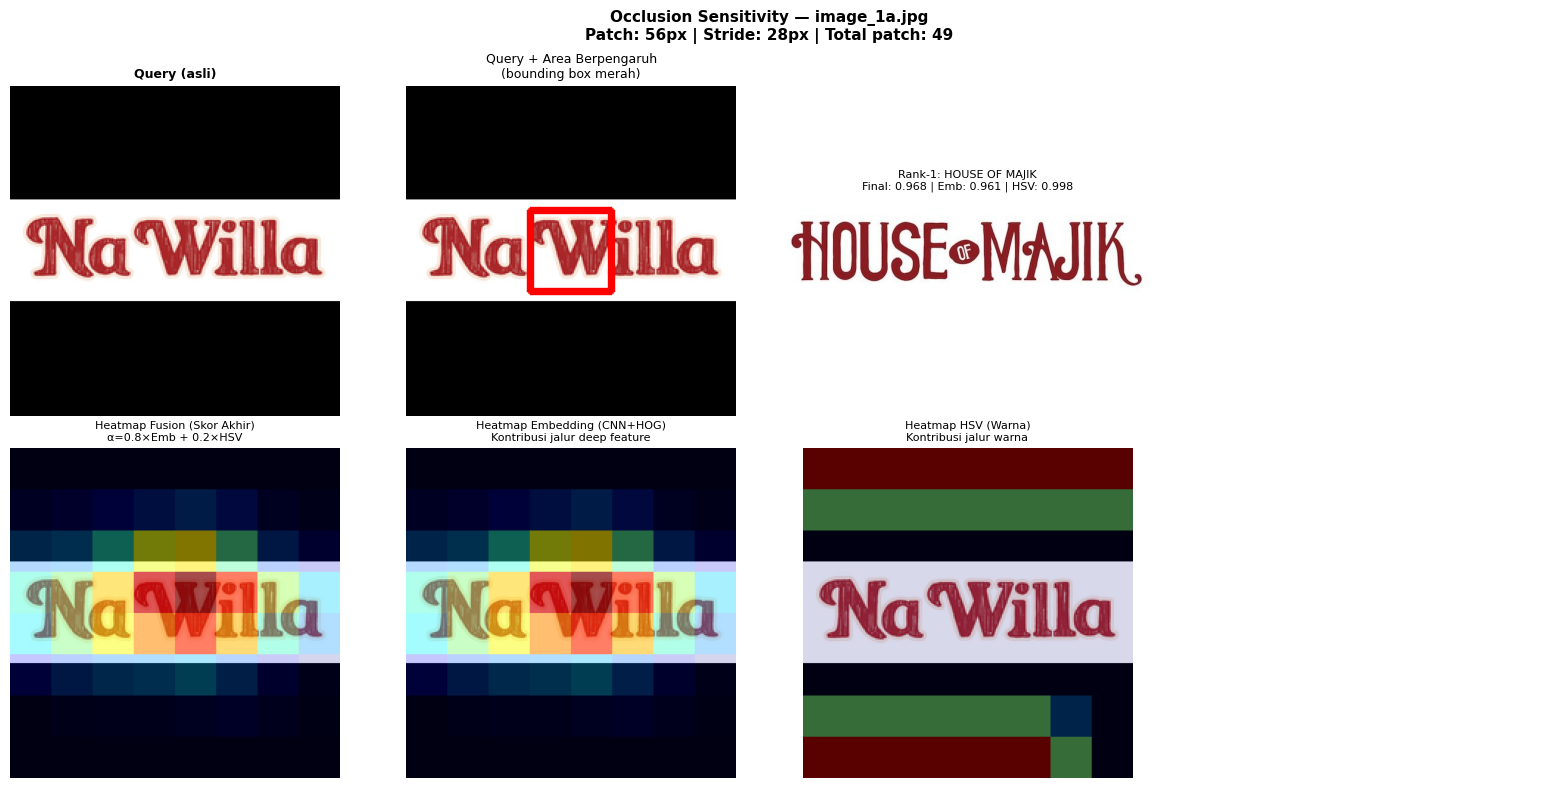

  Skor fusion baseline: 0.9683
  Area paling berpengaruh: (84, 84, 140, 140)

Query 2: image_49.jpg


/tmp/ipykernel_58/2050853492.py:52: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  images.append(Image.fromarray(np.clip(occ, 0, 255).astype(np.uint8), 'RGB'))


  Total patch: 49 | Patch size: 56px | Stride: 28px
  Tersimpan: /kaggle/working/results/bab4/occlusion_sensitivity_2.png


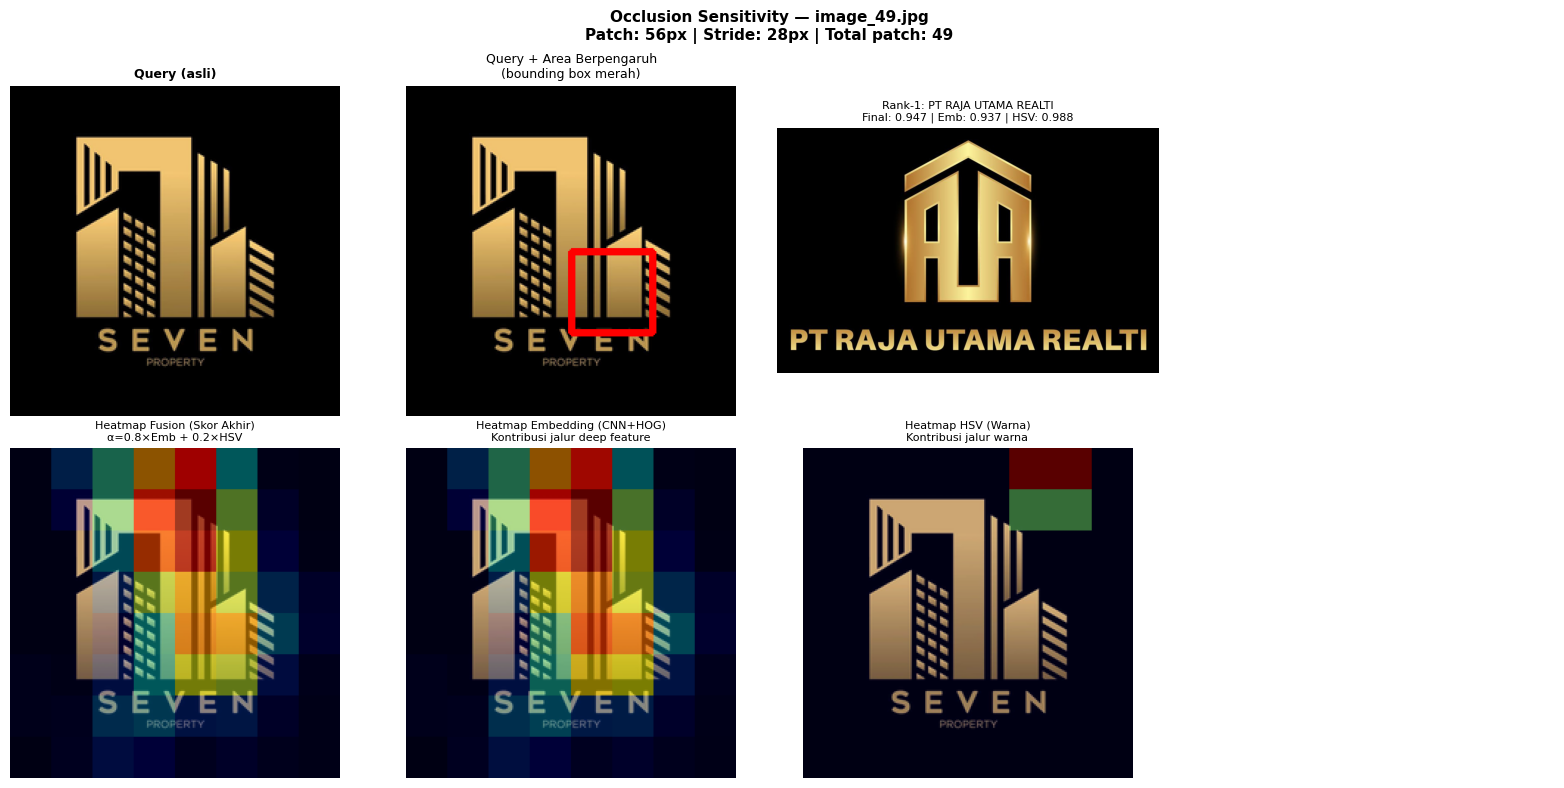

  Skor fusion baseline: 0.9472
  Area paling berpengaruh: (112, 112, 168, 168)

Query 3: image_2.jpg


/tmp/ipykernel_58/2050853492.py:52: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  images.append(Image.fromarray(np.clip(occ, 0, 255).astype(np.uint8), 'RGB'))


  Total patch: 49 | Patch size: 56px | Stride: 28px
  Tersimpan: /kaggle/working/results/bab4/occlusion_sensitivity_3.png


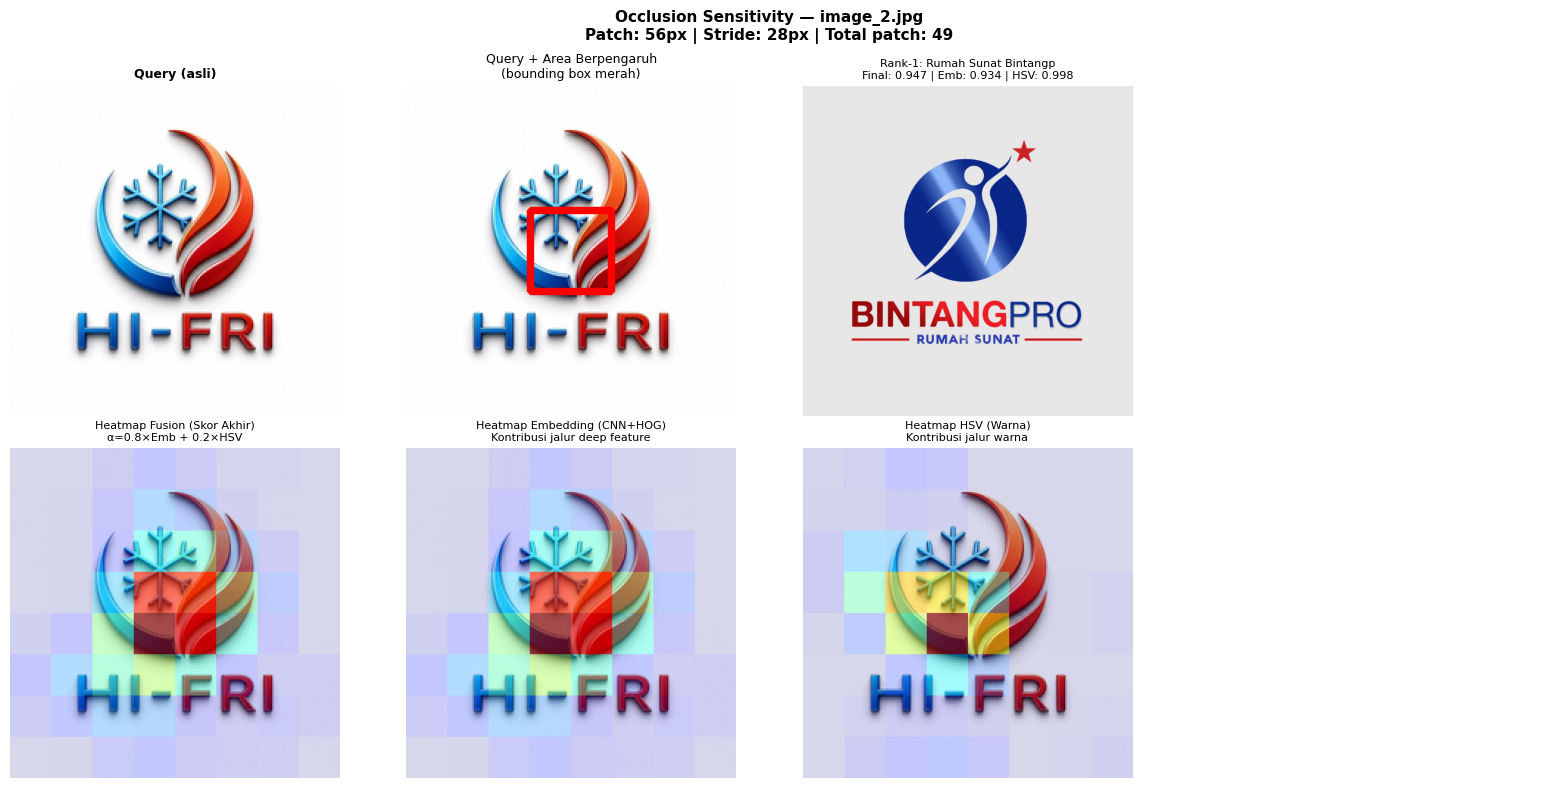

  Skor fusion baseline: 0.9470
  Area paling berpengaruh: (84, 84, 140, 140)

Selesai! File tersimpan di results/bab4/


In [113]:
import cv2
from scipy.ndimage import gaussian_filter

# ── KONFIGURASI ──────────────────────────────────────────────
PATCH_SIZE = 56    # ukuran patch oklusi (piksel) — lebih kecil = lebih detail tapi lebih lama
STRIDE     = 28    # stride sliding window
OCC_BATCH  = 16    # batch size saat inferensi gambar ter-oklusi
ALPHA_OCC  = ALPHA_FUSION   # pakai alpha yang sama dengan sistem

# ── HELPER FUNCTIONS ─────────────────────────────────────────

def _sliding_positions(length, patch_size, stride):
    patch_size = min(patch_size, length)
    last = length - patch_size
    positions = list(range(0, last + 1, stride))
    if not positions:
        positions = [0]
    elif positions[-1] != last:
        positions.append(last)
    return positions

def _make_occluded_images(image_pil, patch_size, stride):
    """Buat variasi logo query dengan area lokal ditutup.
    Fill color dari median border gambar (bukan hitam polos)
    agar edge artifisial tidak mengganggu HOG."""
    lb = LetterboxResize(IMG_SIZE)(image_pil)
    base = np.asarray(lb, dtype=np.float32)

    bw = max(4, IMG_SIZE // 28)
    border = np.concatenate([
        base[:bw, :, :].reshape(-1, 3),
        base[-bw:, :, :].reshape(-1, 3),
        base[:, :bw, :].reshape(-1, 3),
        base[:, -bw:, :].reshape(-1, 3),
    ], axis=0)
    fill_color = np.median(border, axis=0).astype(np.float32)

    xs = _sliding_positions(IMG_SIZE, patch_size, stride)
    ys = _sliding_positions(IMG_SIZE, patch_size, stride)
    feather = max(2.0, patch_size / 12.0)

    images, coords = [], []
    for y0 in ys:
        for x0 in xs:
            x1 = min(IMG_SIZE, x0 + patch_size)
            y1 = min(IMG_SIZE, y0 + patch_size)
            mask = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.float32)
            mask[y0:y1, x0:x1] = 1.0
            mask = cv2.GaussianBlur(mask, (0, 0), feather, feather)
            mask = np.clip(mask, 0, 1)[..., None]
            occ = base * (1 - mask) + fill_color.reshape(1, 1, 3) * mask
            images.append(Image.fromarray(np.clip(occ, 0, 255).astype(np.uint8), 'RGB'))
            coords.append((x0, y0, x1, y1))
    return base.astype(np.uint8), images, coords

@torch.no_grad()
def _extract_occluded_features(images, model, batch_size=OCC_BATCH):
    """Ekstrak embedding + HSV dari semua gambar ter-oklusi secara batch."""
    eff_tensors, hog_vecs, hsv_vecs = [], [], []
    for img in images:
        t_eff = tf_eff_val(img)
        t_hc  = tf_hc_val(img)
        eff_tensors.append(t_eff)
        hog_vecs.append(extract_hog(t_hc))
        hsv_raw = extract_hsv_histogram(t_hc)
        norm = np.linalg.norm(hsv_raw)
        hsv_vecs.append(hsv_raw / (norm + 1e-8))

    all_embs = []
    for s in range(0, len(images), batch_size):
        e = min(len(images), s + batch_size)
        img_b = torch.stack(eff_tensors[s:e]).to(DEVICE)
        hog_b = torch.tensor(np.stack(hog_vecs[s:e]), dtype=torch.float32).to(DEVICE)
        emb_b = model(img_b, hog_b).cpu().numpy()
        all_embs.append(emb_b.astype(np.float32))

    embeddings = np.concatenate(all_embs, axis=0)
    # L2 normalize rows
    norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
    embeddings = embeddings / (norms + 1e-8)

    hsv_arr  = np.stack(hsv_vecs, axis=0)
    hsv_norms = np.linalg.norm(hsv_arr, axis=1, keepdims=True)
    hsv_arr  = hsv_arr / (hsv_norms + 1e-8)

    return embeddings, hsv_arr

def _build_sensitivity_map(score_drops, coords):
    """Akumulasi score drop ke sensitivity map 224×224."""
    canvas = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.float32)
    counts = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.float32)
    pos_drops = np.maximum(np.asarray(score_drops, dtype=np.float32), 0.0)
    for drop, (x0, y0, x1, y1) in zip(pos_drops, coords):
        canvas[y0:y1, x0:x1] += float(drop)
        counts[y0:y1, x0:x1] += 1.0
    raw = np.divide(canvas, counts, out=np.zeros_like(canvas), where=counts > 0)
    mx = raw.max()
    normalized = raw / mx if mx > 1e-12 else np.zeros_like(raw)
    return raw, normalized.astype(np.float32)

def _to_heatmap_rgb(normalized_map):
    """Konversi normalized map ke RGB heatmap (colormap JET)."""
    uint8 = (np.clip(normalized_map, 0, 1) * 255).astype(np.uint8)
    colored = cv2.applyColorMap(uint8, cv2.COLORMAP_JET)
    return cv2.cvtColor(colored, cv2.COLOR_BGR2RGB)

def _overlay(base_rgb, normalized_map):
    """Overlay heatmap ke gambar asli."""
    base_f   = base_rgb.astype(np.float32)
    heat_f   = _to_heatmap_rgb(normalized_map).astype(np.float32)
    strength = np.clip(normalized_map, 0, 1)[..., None]
    alpha_m  = 0.15 + 0.55 * strength
    result   = base_f * (1 - alpha_m) + heat_f * alpha_m
    return np.clip(result, 0, 255).astype(np.uint8)

def _draw_box(base_rgb, box):
    out = base_rgb.copy()
    x0, y0, x1, y1 = box
    cv2.rectangle(out, (x0, y0), (max(x0, x1-1), max(y0, y1-1)), (255, 0, 0), 3)
    return out

# ── FUNGSI UTAMA ──────────────────────────────────────────────

def compute_and_visualize_occlusion(
    query_path,
    db_embeds,
    db_hsv,
    db_meta,
    patch_size=PATCH_SIZE,
    stride=STRIDE,
    alpha=ALPHA_OCC,
    save_path=None,
):
    """
    Hitung Occlusion Sensitivity untuk satu logo query terhadap Rank-1 kandidat.
    Menghasilkan 4 panel: gambar asli + bounding box, heatmap fusion, embedding, HSV.
    """
    model.eval()
    img_pil = Image.open(query_path).convert('RGB')

    # Step 1: Dapatkan embedding & HSV query (baseline)
    t_eff = tf_eff_val(img_pil).unsqueeze(0).to(DEVICE)
    t_hc  = tf_hc_val(img_pil)
    hog_v = torch.tensor(extract_hog(t_hc), dtype=torch.float32).unsqueeze(0).to(DEVICE)
    hsv_q = extract_hsv_histogram(t_hc)
    hsv_q = hsv_q / (np.linalg.norm(hsv_q) + 1e-8)

    with torch.no_grad():
        emb_q = model(t_eff, hog_v).cpu().numpy().flatten()
    emb_q = emb_q / (np.linalg.norm(emb_q) + 1e-8)

    # Step 2: Retrieval — cari Rank-1
    hybrid_scores = cosine_similarity(emb_q.reshape(1, -1), db_embeds).flatten()
    color_scores  = cosine_similarity(hsv_q.reshape(1, -1), db_hsv).flatten()
    final_scores  = alpha * hybrid_scores + (1 - alpha) * color_scores

    query_abs = os.path.abspath(str(query_path))
    for j, meta in enumerate(db_meta):
        if os.path.abspath(str(meta['path'])) == query_abs:
            final_scores[j] = -999
            break

    rank1_idx = int(np.argmax(final_scores))
    ref_emb   = db_embeds[rank1_idx]
    ref_hsv   = db_hsv[rank1_idx]
    ref_emb   = ref_emb / (np.linalg.norm(ref_emb) + 1e-8)
    ref_hsv   = ref_hsv / (np.linalg.norm(ref_hsv) + 1e-8)

    baseline_emb_score = float(emb_q @ ref_emb)
    baseline_hsv_score = float(hsv_q @ ref_hsv)
    baseline_final     = alpha * baseline_emb_score + (1 - alpha) * baseline_hsv_score

    # Step 3: Buat gambar ter-oklusi
    base_rgb, occ_images, coords = _make_occluded_images(img_pil, patch_size, stride)
    print(f'  Total patch: {len(coords)} | Patch size: {patch_size}px | Stride: {stride}px')

    # Step 4: Ekstrak fitur dari semua gambar ter-oklusi
    occ_embs, occ_hsv = _extract_occluded_features(occ_images, model)

    # Step 5: Hitung score drop per komponen
    occ_emb_scores   = (occ_embs @ ref_emb).astype(np.float32)
    occ_hsv_scores   = (occ_hsv  @ ref_hsv).astype(np.float32)
    occ_final_scores = (alpha * occ_emb_scores + (1 - alpha) * occ_hsv_scores)

    emb_drops   = baseline_emb_score   - occ_emb_scores
    hsv_drops   = baseline_hsv_score   - occ_hsv_scores
    final_drops = baseline_final       - occ_final_scores

    # Step 6: Bangun sensitivity maps
    _, norm_final = _build_sensitivity_map(final_drops, coords)
    _, norm_emb   = _build_sensitivity_map(emb_drops,   coords)
    _, norm_hsv   = _build_sensitivity_map(hsv_drops,   coords)

    # Step 7: Temukan area paling berpengaruh
    strongest_idx = int(np.argmax(np.maximum(final_drops, 0)))
    strongest_box = coords[strongest_idx]
    boxed_rgb     = _draw_box(base_rgb, strongest_box)

    # Step 8: Visualisasi
    rank1_meta = db_meta[rank1_idx]
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))

    # Baris atas: gambar query & kandidat Rank-1
    axes[0][0].imshow(base_rgb)
    axes[0][0].set_title('Query (asli)', fontweight='bold', fontsize=9)
    axes[0][0].axis('off')

    axes[0][1].imshow(boxed_rgb)
    axes[0][1].set_title(f'Query + Area Berpengaruh\n(bounding box merah)', fontsize=9)
    axes[0][1].axis('off')

    try:
        rank1_img = Image.open(rank1_meta['path']).convert('RGB')
        axes[0][2].imshow(rank1_img)
    except:
        axes[0][2].text(0.5, 0.5, 'Error', ha='center', transform=axes[0][2].transAxes)
    axes[0][2].set_title(
        f'Rank-1: {rank1_meta.get("nama_merek","N/A")[:20]}\n'
        f'Final: {baseline_final:.3f} | Emb: {baseline_emb_score:.3f} | HSV: {baseline_hsv_score:.3f}',
        fontsize=8
    )
    axes[0][2].axis('off')
    axes[0][3].axis('off')

    # Baris bawah: 3 heatmap
    for ax, norm_map, title, subtitle in [
        (axes[1][0], norm_final, 'Heatmap Fusion (Skor Akhir)',
         f'α={alpha:.1f}×Emb + {1-alpha:.1f}×HSV'),
        (axes[1][1], norm_emb,   'Heatmap Embedding (CNN+HOG)',
         'Kontribusi jalur deep feature'),
        (axes[1][2], norm_hsv,   'Heatmap HSV (Warna)',
         'Kontribusi jalur warna'),
    ]:
        ax.imshow(_overlay(base_rgb, norm_map))
        ax.set_title(f'{title}\n{subtitle}', fontsize=8)
        ax.axis('off')

    axes[1][3].axis('off')

    plt.suptitle(
        f'Occlusion Sensitivity — {Path(query_path).name}\n'
        f'Patch: {patch_size}px | Stride: {stride}px | Total patch: {len(coords)}',
        fontsize=11, fontweight='bold'
    )
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'  Tersimpan: {save_path}')
    plt.show()

    return {
        'baseline_final': baseline_final,
        'baseline_emb':   baseline_emb_score,
        'baseline_hsv':   baseline_hsv_score,
        'strongest_box':  strongest_box,
        'patch_count':    len(coords),
    }


# ── JALANKAN untuk 3 contoh query dari PDKI ──────────────────
print('Generating Occlusion Sensitivity untuk 3 contoh query...')
print(f'Konfigurasi: patch_size={PATCH_SIZE}, stride={STRIDE}, alpha={ALPHA_OCC}')
print()

for i, qpath in enumerate(sample_paths, 1): 
    print(f'Query {i}: {Path(qpath).name}')
    result = compute_and_visualize_occlusion(
        qpath,
        db_embeds, db_hsv, db_meta,
        patch_size=PATCH_SIZE,
        stride=STRIDE,
        alpha=ALPHA_OCC,
        save_path=f'{BASE_OUT}/results/bab4/occlusion_sensitivity_{i}.png',
    )
    print(f'  Skor fusion baseline: {result["baseline_final"]:.4f}')
    print(f'  Area paling berpengaruh: {result["strongest_box"]}')
    print()

print('Selesai! File tersimpan di results/bab4/')

## Cell 21 — Ringkasan Final & Checklist Download

In [20]:
print('='*70)
print('RINGKASAN HASIL — SIAP MASUK BAB 4')
print('='*70)
print(f'\nDataset training : Logo-2K+ Food (clean, 214 brand, ~10K gambar)')
print(f'Dataset evaluasi : METU Query Set (417 logo, 35 grup)')
print(f'Database demo    : PDKI Indonesia ({len(db_meta)} logo)')
print(f'\nHASIL BASELINE COMPARISON:')
print(df_comparison.to_string())
print(f'\nFILE TERSIMPAN DI {BASE_OUT}/results/bab4/')
bab4_files = [
    'training_loss_hybrid.png       -- grafik training loss (Bab 4.3)',
    'baseline_comparison.csv        -- tabel perbandingan (Bab 4.4)',
    'tabel_baseline_comparison.png  -- tabel perbandingan siap screenshot',
    'retrieval_demo_1/2/3.png       -- contoh hasil retrieval (Bab 4.5)',
    'gradcam_1/2/3.png              -- visualisasi Grad-CAM++ (Bab 4.6)',
]
for f in bab4_files:
    print(f'  {f}')
print(f'\nFILE MODEL TERSIMPAN DI {BASE_OUT}/models/')
model_files = [
    'hybrid_best.pt          -- model hybrid terbaik',
    'pdki_embeddings.npy     -- embedding database PDKI',
    'pdki_hsv.npy            -- HSV histogram database PDKI',
    'pdki_metadata.json      -- metadata path + brand tiap logo PDKI',
]
for f in model_files:
    print(f'  {f}')
print('='*70)
print('DOWNLOAD SEMUA FILE SEBELUM SESI KAGGLE BERAKHIR!')

RINGKASAN HASIL — SIAP MASUK BAB 4

Dataset training : Logo-2K+ Food (clean, 214 brand, ~10K gambar)
Dataset evaluasi : METU Query Set (417 logo, 35 grup)
Database demo    : PDKI Indonesia (6698 logo)

HASIL BASELINE COMPARISON:
                                mAP    P@10    R@10  nDCG@10
Pretrained Only (Baseline)   0.6981  0.4058  0.3716   0.7805
Handcrafted Only (HOG+HSV)   0.4796  0.1959  0.1780   0.5517
Hybrid Early Fusion (α=1.0)  0.6898  0.3914  0.3546   0.7802
Hybrid Full (α=0.9)          0.6764  0.3746  0.3398   0.7647

FILE TERSIMPAN DI /kaggle/working/results/bab4/
  training_loss_hybrid.png       -- grafik training loss (Bab 4.3)
  baseline_comparison.csv        -- tabel perbandingan (Bab 4.4)
  tabel_baseline_comparison.png  -- tabel perbandingan siap screenshot
  retrieval_demo_1/2/3.png       -- contoh hasil retrieval (Bab 4.5)
  gradcam_1/2/3.png              -- visualisasi Grad-CAM++ (Bab 4.6)

FILE MODEL TERSIMPAN DI /kaggle/working/models/
  hybrid_best.pt          -